# Mean to osculating elements

This notebooks demonstrates how to convert from the osculating elements used by the the TTV posteriors to the mean elements implicitly used when representing the phase space state of a given system. The [`celmech` package](https://celmech.readthedocs.io/en/latest/) is used to effect the transformation.

In [1]:
from resonantstate.data_download  import get_metadata_observations, download_observations_samples
from resonantstate.constants import *
dataframe_observations = get_metadata_observations()

We'll use the Kepler-11 system as an example

In [2]:
star='Kepler-11'
dataframe_system = dataframe_observations[(dataframe_observations["star_name"]==star)]

dataframe_system_dl = dataframe_system[(dataframe_system['author_name']=='Hadden')&(dataframe_system['default']==True)]
list_analysis = download_observations_samples(dataframe_system_dl, download_destination=None)

df_samples=list_analysis[0]['samples']
nb_planets=list_analysis[0]['nb_planets']


### Converting elements of a single $N$-body simulation

We'll start by initializing a single $N$-body simulation of the first sample in the posterior (`sample_id=0`).

In [3]:
from rebound_db import get_rebound_sim_coplanar
sample_id = 0
sim = get_rebound_sim_coplanar(
    df_samples,
    [_ for _ in range(nb_planets)],
    sample_id
)

We'll use the [`FirstOrderGeneratingFunction` class](https://celmech.readthedocs.io/en/latest/canonical_transformations.html#lie-series-transformations) to construct a transformation from osculating elements to mean elements. This transformation eliminates  high-frequency oscillations in the osculating elements associated with individual terms in the [disturbing function](https://celmech.readthedocs.io/en/latest/disturbing_function.html).

Individual distrubing function terms are eliminated by adding terms to our `FirstOrderGeneratingFunction` instance, `chi`.

 - `chi.add_zeroth_order_term` elliminates oscillations at all harmonics of the synodic frequency, $n_i-n_j$, between a pair of planets $i$ and $j$ to zeroth order in eccentricity and inclination. Below, we only eliminate terms between adjacent planet pairs as these are usually the most significant
 - `chi.add_MMR_terms` elliminates terms generated by a $p:p-q$ MMR with frequency $p n_j - (p-q) n_i$. Below, we elimnate terms associated with first-order, $p:p-1$ MMRs between adjacent planets. We take $p$ to be $(p^*-1,p^*,p^*+1)$ where $p^*$ is the index of closest first-order MMR.

In the example below we will correct for the effect of the nearest MMR of each pair. These terms produce oscillations that occur over the familiar 'super-period' seen in TTVs. Note that these corrections will fail for pairs of planets that are *in* resonance, but none of the Kepler-11 planets are actually in resonance. 

Corrections for the nearest MMR should **not** be applied when converting posterior samples to the varaibles used by the SFMR (see below).

In [4]:
import celmech as cm
from celmech.lie_transformations import FirstOrderGeneratingFunction

chi = FirstOrderGeneratingFunction(cm.Poincare.from_Simulation(sim))
for i in range(1,nb_planets-1):
    chi.add_zeroth_order_term(indexIn=i,indexOut=i+1)
    nearest_first_order = int(np.round(1/(1 - chi.particles[i].P/chi.particles[i+1].P)))
    # correct for the nearest f.o. mmr + two adjacent mmrs
    for dj in (-1,0,1):
        chi.add_MMR_terms(nearest_first_order+dj,1,max_order=1,indexIn=i,indexOut=i+1,l_max = 1)
        
print("Osculating periods [days]:",np.array2string(np.array([p.P * 365.25 for p in chi.particles[1:]]),precision = 4))
print("Osculating eccentricities:",np.array2string(np.array([p.e for p in chi.particles[1:]]),precision=4))
# note-- this takes a little bit of time to initialze the transformation function
chi.osculating_to_mean()
print("Mean periods [days]:",np.array2string(np.array([p.P * 365.25 for p in chi.particles[1:]]),precision = 4))
print("Mean eccentricities:",np.array2string(np.array([p.e for p in chi.particles[1:]]),precision=4))

Osculating periods [days]: [10.3042 13.0232 22.691  32.0041 46.6934]
Osculating eccentricities: [0.0498 0.0133 0.0027 0.0085 0.0197]
Mean periods [days]: [10.3032 13.0247 22.6879 32.0072 46.6934]
Mean eccentricities: [0.0502 0.013  0.0025 0.0083 0.0197]


Now we'll run our integration and record both mean and osculating eccentricities

In [5]:
times = np.linspace(0,100,200)
eccs_osc = np.zeros((nb_planets,len(times)))
eccs_mean = np.zeros((nb_planets,len(times)))

for i,t in enumerate(times):
    sim.integrate(t)
    osculating_pvar_values = cm.Poincare.from_Simulation(sim).values
    mean_pvar_values = chi.osculating_to_mean_state_vector(osculating_pvar_values)
    chi.state.values = mean_pvar_values
    
    eccs_mean[:,i] = [ p.e for p in chi.state.particles[1:]]
    eccs_osc[:,i] = [ p.e for p in sim.particles[1:]]



In [6]:
from matplotlib import pyplot as plt

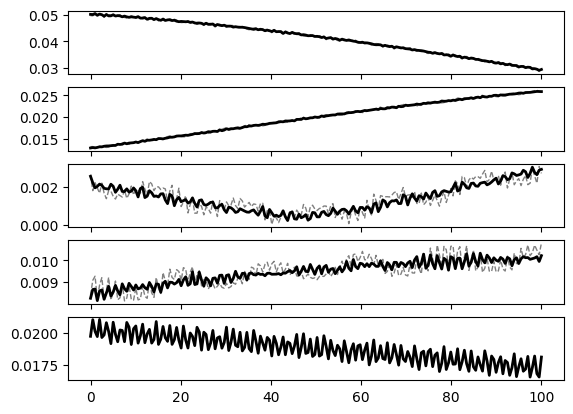

In [7]:
fig,axes = plt.subplots(nb_planets,1,sharex=True)
for i,ax in enumerate(axes):
    ax.plot(times,eccs_osc[i],ls='--',lw=1,color = 'gray')
    ax.plot(times,eccs_mean[i],ls='-',lw=2,color='black')
    

# Correcting multiple posterior samples

Now we'll look at applying our osculating-to-mean correction to all of the posterior samples of a given system. Doing this efficiently will entail applying some `sympy` tricks in order to develop a function that converts from osculating elements to mean ones as a function of both the current state of a given system *as well as* the masses, which vary among the different posterior samples.

We'll take Kelper-307 as our target system

In [8]:
target = "Kepler-307"

df_selected = dataframe_observations[dataframe_observations["star_name"].isin([target])]
df_list = download_observations_samples(df_selected)

In [9]:
[vals['author_name'] for vals in df_list]

['Hadden', 'Hadden', 'Ragozzine']

In [10]:
samples_dict = df_list[1]
print(f"Samples by {samples_dict['author_name']} using a '{samples_dict['mass_prior']}' prior on mass and '{samples_dict['eccentricity_prior']}' prior on eccentricities")

Samples by Hadden using a 'uniform' prior on mass and 'log-uniform' prior on eccentricities


In [11]:
df_samples = samples_dict['samples']
nb_planets = samples_dict['nb_planets']

We'll use the first posterior entry to create our initial `FirstOrderGeneratingFunction` object. Since we will be applying the SFMR to our corrected samples, we will not correct for resonances that adjacent planet pairs are in/near.

Planet 1 and 2 near 5:4
Osculating Delta:  0.0035481600910995947
Mean Delta:  0.005041688996063831


Text(0, 0.5, '$\\Delta$')

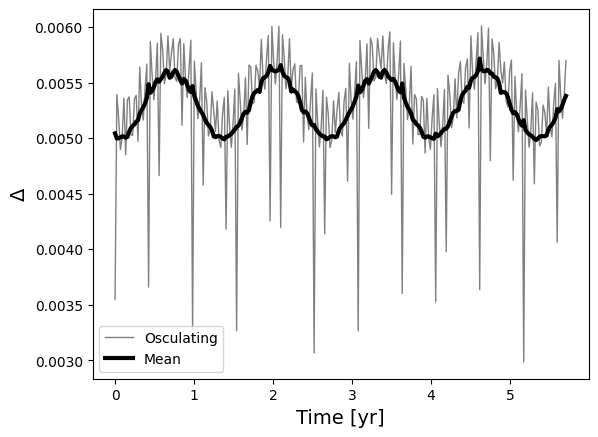

In [12]:
import rebound as rb
import celmech as cm
sim = get_rebound_sim_coplanar(df_samples,[_ for _ in range(nb_planets)],0)
pvars = cm.Poincare.from_Simulation(sim)
chi = FirstOrderGeneratingFunction(pvars)

for i in range(1,nb_planets):
    
    chi.add_zeroth_order_term(indexIn=i,indexOut=i+1)
    nearest_first_order = int(np.round(1/(1 - chi.particles[i].P/chi.particles[i+1].P)))
    print(f"Planet {i} and {i+1} near {nearest_first_order}:{nearest_first_order-1}")
    # No dj = 0: Since we want to capture the dynamics with the SFMR, we should not eliminate
    # the resonant terms that form part of the model.
    for dj in (-4,-3,-2,-1,1,2,3,4):
        k = nearest_first_order+dj
        chi.add_MMR_terms(k,1,max_order=1,indexIn=i,indexOut=i+1,l_max = 1)

print("Osculating Delta: ",(pvars.particles[2].P/pvars.particles[1].P) * (4/5) - 1)
chi.osculating_to_mean()
print("Mean Delta: ", (pvars.particles[2].P/pvars.particles[1].P) * (4/5) - 1)

sim = get_rebound_sim_coplanar(df_samples,[_ for _ in range(nb_planets)],0)
Tfin = 200 * sim.particles[1].P
sim.save_to_file(target+".sa",interval=Tfin / 256,delete_file=True)
sim.integrate(Tfin)
sa = rb.Simulationarchive(target+".sa")
times = np.zeros(len(sa))
Delta_osc,Delta_mean = np.zeros((2,len(sa)))
for i,sim in enumerate(sa):
    times[i] = sim.t
    pvars = cm.Poincare.from_Simulation(sim)
    Delta_osc[i] = (pvars.particles[2].P/pvars.particles[1].P) * (4/5) - 1
    pvars.values = chi.osculating_to_mean_state_vector(pvars.values)
    Delta_mean[i] = (pvars.particles[2].P/pvars.particles[1].P) * (4/5) - 1
plt.plot(times,Delta_osc,lw=1,color='gray',label="Osculating")
plt.plot(times,Delta_mean,lw=3,color='black',label="Mean")
plt.legend()
plt.xlabel("Time [yr]",fontsize=14)
plt.ylabel(r"$\Delta$",fontsize=14)

Now we'll use the `FirstOrderGeneratingFunction` object that we created above to correct **all** of the posterior samples. Because different posterior samples have different planet masses, we'll need apply some `sympy` tricks to get a mass-dependent function that allows us to go from osculating to mean variables.

A function $f$, of the mean variables, $\bar{x}$, is given, in terms of osculating variables, $x$, by 
$$f(\bar{x})=(\exp[-\mathcal{L}_\chi]f)(x)\approx (f - \mathcal{L}_\chi f)(x).$$
Taking $f$ as the identity function below, we create a function that converts from osculating to mean variables. We use `sympy`'s `lambidfy` function in order to convert symbolic expressions into numerical functions.

In [13]:
import sympy as sp
from celmech.poincare import _get_a0_symbol,_get_Lambda0_symbol
params = chi.H_params.copy()
G = sp.symbols("G")
Ms = sp.symbols(f"M(1:{nb_planets+1})")
ms = sp.symbols(f"m(1:{nb_planets+1})")
mus = sp.symbols(f"mu(1:{nb_planets+1})")

# we'll approximate each occurence of mu_i by m_i, as they are nearly identical
mu_to_m = dict(zip(mus,ms))

# The values of the parameters Lambda_{i,0} implicitly depend on planet masses.
# We'll make this dependence explicit
Lambda0_rule=dict()
for i,m in enumerate(ms):
    Lambda0_rule[_get_Lambda0_symbol(i+1)] = m*sp.sqrt(G*Ms[i] * _get_a0_symbol(i+1))

# remove mass parameters from params dictionary
for m,mu in zip(ms,mus):
    params.pop(m)
    params.pop(mu)

osc_to_mean_exprn = sp.Matrix([v - chi.Lie_deriv(v).xreplace(Lambda0_rule).xreplace(params).xreplace(mu_to_m) for v in chi.qp_vars])

osc_to_mean_function = sp.lambdify(chi.qp_vars + list(ms), osc_to_mean_exprn, **chi._lambdify_kwargs)

def osc_to_mean(pvars):
    new_vals = osc_to_mean_function(*pvars.values,*[p.m for p in pvars.particles[1:]]).reshape(-1)
    pvars.values = new_vals

Now we'll loop over our posterior samples and convert from osculating to mean elements:

In [14]:
import pandas as pd
import celmech as cm

rad2deg = 180 / np.pi
new_rows = []

for sample_id, row in df_samples.iterrows():
    sim = get_rebound_sim_coplanar(
        df_samples,
        range(nb_planets),
        sample_id
    )

    pvars = cm.Poincare.from_Simulation(sim)
    osc_to_mean(pvars)
    sim_mean = pvars.to_Simulation()

    orbits = sim_mean.orbits(primary=sim_mean.particles[0])
    mstar = sim_mean.particles[0].m

    # Convert the original row to a mutable dictionary.
    new_row = row.to_dict()

    for planet_id, orbit in enumerate(orbits):
        new_row.update({
            f"mean_longitude_deg_{planet_id}": orbit.l * rad2deg,
            f"period_days_{planet_id}": orbit.P * 365.25,
            f"k_{planet_id}": orbit.pal_k,
            f"h_{planet_id}": orbit.pal_h,
            f"mass_planet_star_ratio_{planet_id}":
                sim_mean.particles[planet_id + 1].m / mstar,
        })

    new_rows.append(new_row)

df_mean = pd.DataFrame(new_rows, index=df_samples.index)

Let's compare the mean and osculating states in the space of the second fundamental model's variables. We see that the mean varia

In [15]:
from resonantstate.data_download  import get_metadata_observations, download_observations_samples
#from resonantstate.analyse_samples import *
from resonantstate.ell2SFM import *
from resonantstate.simulations_resonance_analysis import *

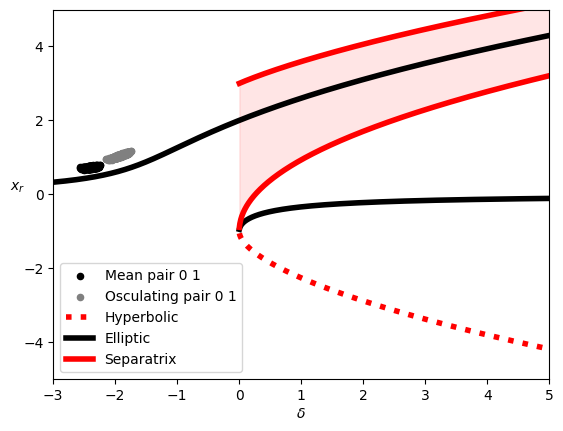

In [29]:
fig,ax = plt.subplots(1)

plot_samples_SFM_pair(ax,df_mean,[0,1],4,'k',flag_DMMR=False,label="Mean")
plot_samples_SFM_pair(ax,df_samples,[0,1],4,'gray',flag_DMMR=False,label="Osculating")
plot_topology(ax)
ax.legend()


To demonstrate that our osculating-to-mean transformation works for posterior samples with different planet masses, we'll apply the transformation to another integration initialized from a different sample and compare it to the transformation generated by a locally-generated transformation function:

Planet 1 and 2 near 5:4


Text(0, 0.5, '$\\Delta$')

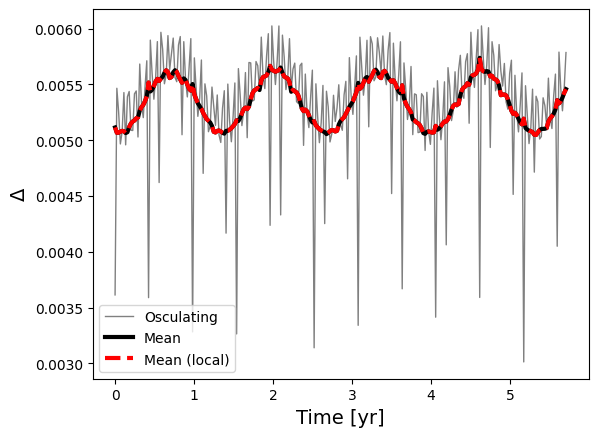

In [17]:
import rebound as rb
import celmech as cm
i_sim = 1000 # index of posterior sample to use

# make a first-order generating function specific to this posterior sample
sim = get_rebound_sim_coplanar(df_samples,[_ for _ in range(nb_planets)],i_sim)
pvars = cm.Poincare.from_Simulation(sim)
chi_local = FirstOrderGeneratingFunction(pvars)
for i in range(1,nb_planets):
    chi_local.add_zeroth_order_term(indexIn=i,indexOut=i+1)
    nearest_first_order = int(np.round(1/(1 - chi.particles[i].P/chi.particles[i+1].P)))
    print(f"Planet {i} and {i+1} near {nearest_first_order}:{nearest_first_order-1}")
    # # correct for the adjacent mmrs
    for dj in (-4,-3,-2,-1,1,2,3,4):
        k = nearest_first_order+dj
        chi_local.add_MMR_terms(k,1,max_order=1,indexIn=i,indexOut=i+1,l_max = 1)


# Run integration
sim = get_rebound_sim_coplanar(df_samples,[_ for _ in range(nb_planets)],i_sim)
Tfin = 200 * sim.particles[1].P
sim.save_to_file(target+".sa",interval=Tfin / 256,delete_file=True)
sim.integrate(Tfin)
sa = rb.Simulationarchive(target+".sa")
times = np.zeros(len(sa))
Delta_osc, Delta_mean_local, Delta_mean = np.zeros((3,len(sa)))

for i,sim in enumerate(sa):
    times[i] = sim.t
    pvars = cm.Poincare.from_Simulation(sim)
    Delta_osc[i] = (pvars.particles[2].P/pvars.particles[1].P) * (4/5) - 1
    pvars.values = chi_local.osculating_to_mean_state_vector(pvars.values)
    Delta_mean_local[i] = (pvars.particles[2].P/pvars.particles[1].P) * (4/5) - 1

    pvars = cm.Poincare.from_Simulation(sim)
    osc_to_mean(pvars)
    Delta_mean[i] = (pvars.particles[2].P/pvars.particles[1].P) * (4/5) - 1
    
plt.plot(times,Delta_osc,lw=1,color='gray',label="Osculating")
plt.plot(times,Delta_mean,lw=3,color='black',label="Mean")
plt.plot(times,Delta_mean_local,lw=3,color='r',ls='--',label="Mean (local)")
plt.legend()
plt.xlabel("Time [yr]",fontsize=14)
plt.ylabel(r"$\Delta$",fontsize=14)